# Interactive Demo: Gaia DR3 Pleiades Cluster Analytics

This notebook demonstrates the end-to-end workflow of `gaia_pyspark_pipeline` to retrieve, clean, and cluster astronomical data from the **Gaia DR3** archive using **PySpark** and **DBSCAN**.

### Pipeline Steps:
1. **Data Retrieval:** Querying Gaia DR3 ADQL around the Pleiades cluster ($RA = 56.75^\circ, Dec = 24.12^\circ$).
2. **Distributed Cleaning:** PySpark quality filtering & benchmark.
3. **ML Clustering:** Kinematic identification via DBSCAN.
4. **Astrophysical Validation:** VPD and CMD plotting.

In [1]:
import pandas as pd
import sys
import os

sys.path.append(os.path.abspath('..'))


In [2]:

from gaia_pipeline.fetch_data import fetch_cluster_data
from gaia_pipeline.spark_cleaner import clean_gaia_pyspark, benchmark_pyspark_performance
from gaia_pipeline.clustering import run_dbscan_clustering, plot_cluster_results

print("Pipeline modules successfully imported!")

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
Pipeline modules successfully imported!


## Step 1: Query Gaia DR3 Archive
We query stars within a $1.0^\circ$ radius around the center of the Pleiades cluster.

In [3]:
import pandas as pd

raw_file = pd.read_parquet("../data/pleiades_chunks.parquet")  

print("--- Information ---")
print(raw_file.info())

print("\n---Sample Data---")
print(raw_file.head(3))


missing_values = raw_file.isnull().sum()
print("---  ---")
print(missing_values[missing_values > 0])

assert len(raw_file) > 0, "⚠️Warning!"

--- Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6778 entries, 0 to 6777
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        6778 non-null   int64  
 1   ra               6778 non-null   float64
 2   dec              6778 non-null   float64
 3   parallax         6778 non-null   float64
 4   pmra             6778 non-null   float64
 5   pmdec            6778 non-null   float64
 6   phot_g_mean_mag  6777 non-null   float32
 7   bp_rp            6726 non-null   float32
 8   parallax_error   6778 non-null   float32
dtypes: float32(3), float64(5), int64(1)
memory usage: 397.3 KB
None

---Sample Data---
           source_id         ra        dec  parallax       pmra      pmdec  \
0  66526127137440128  57.290689  24.053212  8.118448  19.078968 -46.193245   
1  65271996684817280  56.219005  24.113133  8.345685  20.541505 -46.081450   
2  65283232316451328  56.456796  24.367541  7.

In [4]:
print("type:", type(raw_file))

if isinstance(raw_file, dict):
  file_path = raw_file.get("path") or list(raw_file.values())[0]
else:
  file_path = raw_file

print("file path:", file_path)


type: <class 'pandas.core.frame.DataFrame'>
file path:               source_id         ra        dec  parallax       pmra      pmdec  \
0     66526127137440128  57.290689  24.053212  8.118448  19.078968 -46.193245   
1     65271996684817280  56.219005  24.113133  8.345685  20.541505 -46.081450   
2     65283232316451328  56.456796  24.367541  7.671310  19.515752 -45.527310   
3     65205373152172032  56.581671  23.948144  7.067029  13.075220 -48.403790   
4     65296907494549120  56.302163  24.467064  9.544445  16.291673 -47.206094   
...                 ...        ...        ...       ...        ...        ...   
6773  65257355138728832  55.700767  24.066878  8.845350  18.741017 -44.120636   
6774  66727608345339264  56.795685  24.191829  7.522340  -3.147029 -13.371004   
6775  64911386933051392  56.904055  23.131453  7.041347  -1.937900  13.007060   
6776  66741833275728768  56.800476  24.475361  8.010791  19.892623 -46.170769   
6777  65176854567331712  56.430575  23.649087  3.53696

## Step 2: Distributed Data Cleaning (PySpark)
Filter missing values and unphysical negative parallaxes using PySpark.

Succsessfully done

 Measuring PySpark Cleaning Scalability Performance...
  - Scale 20% (1,395 rows): 0.147 seconds
  - Scale 40% (2,748 rows): 0.152 seconds
  - Scale 60% (4,128 rows): 0.168 seconds
  - Scale 80% (5,439 rows): 0.144 seconds
  - Scale 100% (6,726 rows): 0.148 seconds
PySpark Performance graph saved to '../pyspark_performance.png'


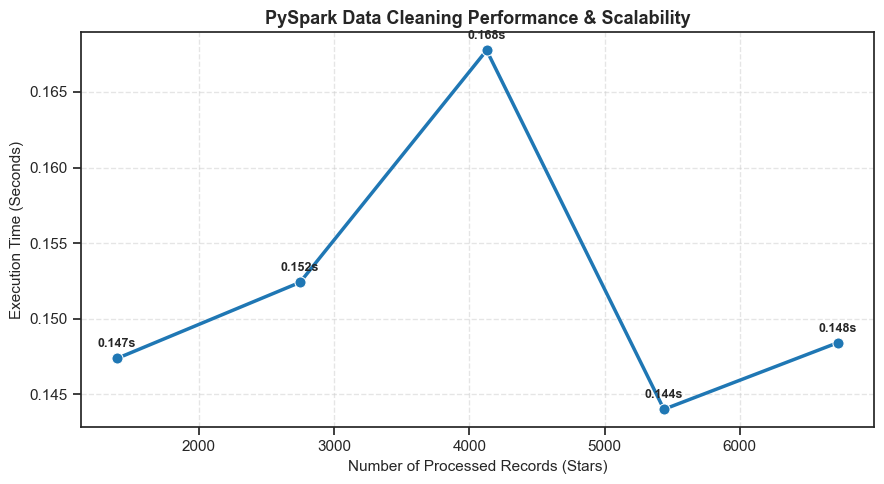

In [6]:
df_spark = clean_gaia_pyspark(input_file="../data/pleiades_chunks.parquet", output_file=None)
print("Succsessfully done")
benchmark_pyspark_performance(df_spark, output_image="../pyspark_performance.png")

## Step 3: Machine Learning Clustering (DBSCAN)
Isolate cluster members based on proper motion parameters (`pmra`, `pmdec`).

In [7]:
df_clustered = run_dbscan_clustering(df_spark)

df_clustered[df_clustered['cluster_Label'] != -1].head(6)

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,parallax_error,cluster_Label
0,66526127137440128,57.290689,24.053212,8.118448,19.078968,-46.193245,3.615795,-0.036376,0.479091,0
1,65271996684817280,56.219005,24.113133,8.345685,20.541505,-46.081450,3.698209,-0.087962,0.438633,0
2,65283232316451328,56.456796,24.367541,7.671310,19.515752,-45.527310,3.863349,-0.013768,0.310423,0
3,65205373152172032,56.581671,23.948144,7.067029,13.075220,-48.403790,4.172742,-0.011191,0.286207,0
5,66529975427235712,57.296831,24.136498,7.241378,19.496054,-47.649899,5.203287,-0.033113,0.125535,0
6,64940906245415808,57.086832,23.421039,7.690936,19.695021,-47.112981,5.428299,-0.067107,0.098538,0


## Step 4: Astrophysical Verification Plots
Plot the Vector Point Diagram (VPD) and Color-Magnitude Diagram (CMD).

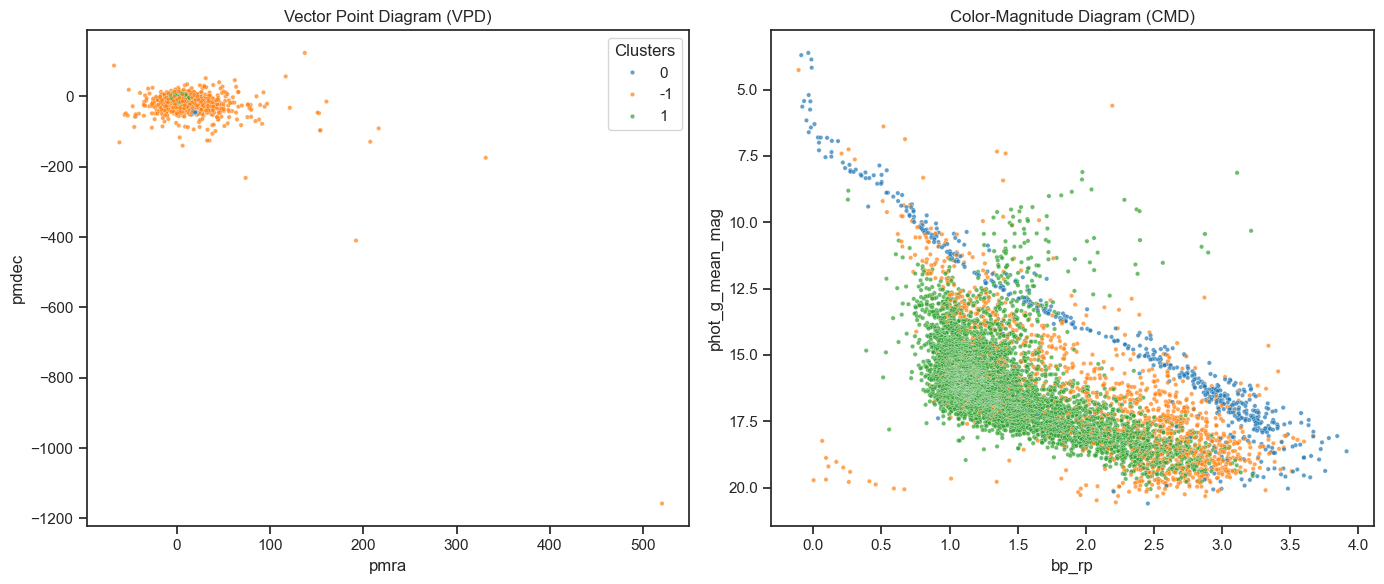

In [9]:
%matplotlib inline
from IPython.display import Image

plot_cluster_results(df_clustered, output_image="../examples/orion_cluster_plot.png")


## Step 5: Summary Statistics

In [10]:
total_stars = len(df_clustered)

print(df_clustered["cluster_Label"].value_counts())

cluster_stars = len(df_clustered[df_clustered["cluster_Label"] != -1])
noise_stars = len(df_clustered[df_clustered["cluster_Label"] == -1])

print(f"Total Stars Processed: {total_stars:,}")
print(
    f"Identified Orion Members: {cluster_stars:,}"
    f" ({cluster_stars / total_stars * 100:.1f}%)"
)
print(f"Field/Background Stars (Noise): {noise_stars:,}")

cluster_Label
 1    4913
-1    1284
 0     529
Name: count, dtype: int64
Total Stars Processed: 6,726
Identified Orion Members: 5,442 (80.9%)
Field/Background Stars (Noise): 1,284
